In [ ]:
import yfinance as yf                        
import pandas as pd                          
import numpy as np                           
import matplotlib.pyplot as plt              
from sklearn.linear_model import LinearRegression             
from sklearn.model_selection import train_test_split    
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

Librabies import


In [19]:
STOCK_TICKER = "AAPL"   
START_DATE   = "2020-01-01"
END_DATE     = "2021-01-01"

df = yf.download(STOCK_TICKER, start=START_DATE, end=END_DATE)

print(f"\nData downloaded!")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()

[*********************100%***********************]  1 of 1 completed


Data downloaded!
Date range: 2020-01-02 to 2020-12-31


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400536,72.460799,71.156697,71.409800,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


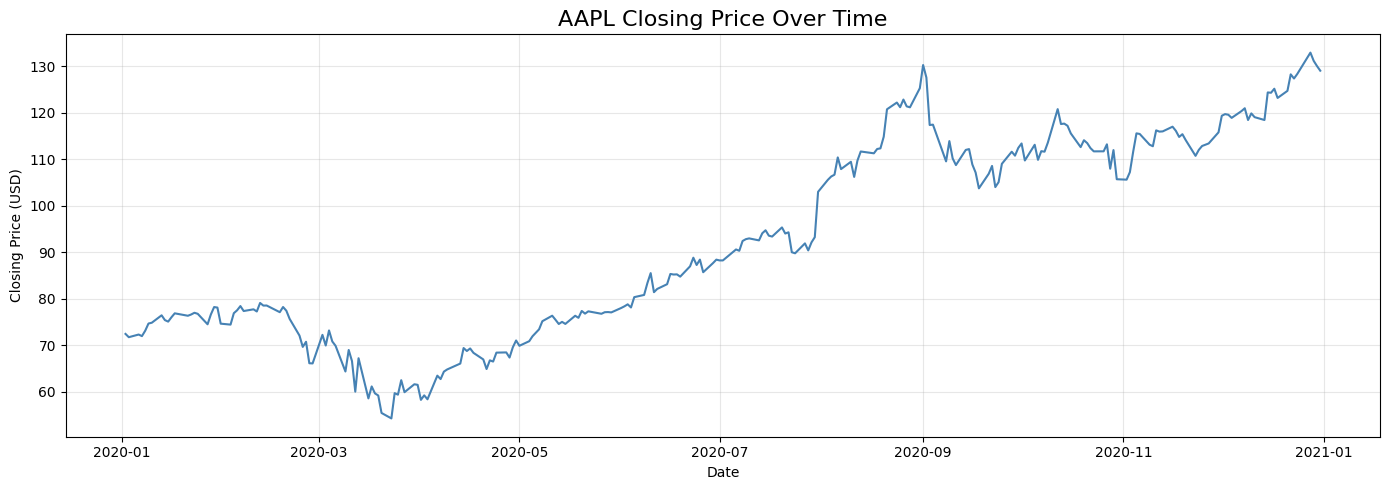

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1.5)
plt.title(f'{STOCK_TICKER} Closing Price Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df['Next_Close'] = df['Close'].shift(-1)

df.dropna(inplace=True)

FEATURES = ['Open', 'High', 'Low', 'Volume']
TARGET   = 'Next_Close'

X = df[FEATURES]
y = df[TARGET]

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print("\nfeatures:")
X.head()

Features shape: (252, 4)
Target shape:   (252,)

First few rows of features:


Price,Open,High,Low,Volume
Date,,,,
2020-01-02,71.409800,72.460799,71.156697,135480400
2020-01-03,71.629153,72.455966,71.472469,146322800
2020-01-06,70.819186,72.306483,70.568488,118387200
2020-01-07,72.277571,72.533087,71.708687,108872000
2020-01-08,71.631567,73.386438,71.631567,132079200


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 201
Testing  samples : 51


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
print("Linear Regression model trained!")

Linear Regression model trained!


In [ ]:
def evaluate_model(name, y_true, y_pred):
    """Prints evaluation metrics for a given model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"  MAE  : ${mae:.2f}")
    print(f"  RMSE : ${rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print()
evaluate_model("Linear Regression", y_test, lr_predictions)


--- Linear Regression ---
  MAE  : $1.78
  RMSE : $2.40
  R²   : 0.8670



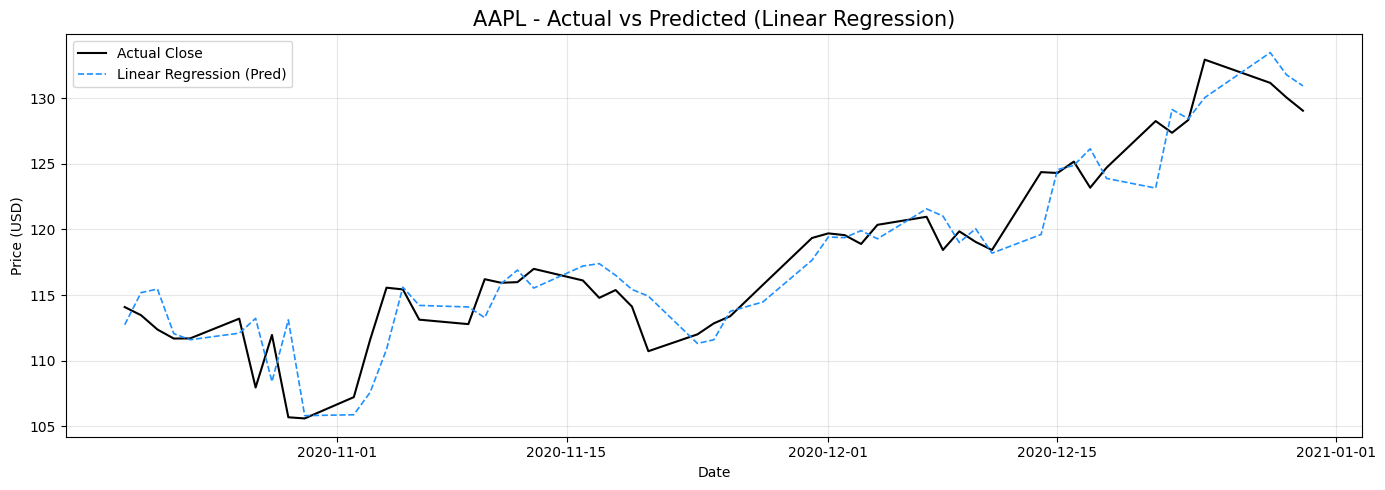

In [ ]:
test_dates = df.index[len(X_train):]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test.values,    label='Actual Close',             color='black',      linewidth=1.5)
plt.plot(test_dates, lr_predictions,   label='Linear Regression (Pred)', color='dodgerblue', linewidth=1.2, linestyle='--')
plt.title(f'{STOCK_TICKER} - Actual vs Predicted (Linear Regression)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
latest_data = X.iloc[[-1]]  

print("Latest available data (used as input):")

print(latest_data.to_string())

lr_next = lr_model.predict(latest_data)[0]

print(f"\n📌 Predicted Next Closing Price: ${lr_next:.2f}")

Latest available data (used as input):
Price             Open        High         Low    Volume
Date                                                    
2020-12-30  131.857222  132.255968  129.737074  96452100

📌 Predicted Next Closing Price: $130.94
